In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sea
import scipy.stats as stats
import statsmodels.api as sm
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression

# um Warnungen zu ignorieren (auf eigene Gefahr!)
import warnings
warnings.filterwarnings("ignore")

### Laden der Daten

In [3]:
penguins = pd.read_excel('penguinsSmall.xlsx', index_col=0)
display(penguins.head(3))

,Individual ID,Species,Island,Date Egg,Culmen Length (mm),Culmen Depth (mm),Flipper Length (mm),Body Mass (g),Sex
0,N1A1,Adelie,Torgersen,2007-11-11,39.1,18.7,181,3750,MALE
1,N1A2,Adelie,Torgersen,2007-11-11,39.5,17.4,186,3800,FEMALE
2,N2A1,Adelie,Torgersen,2007-11-16,40.3,18.0,195,3250,FEMALE


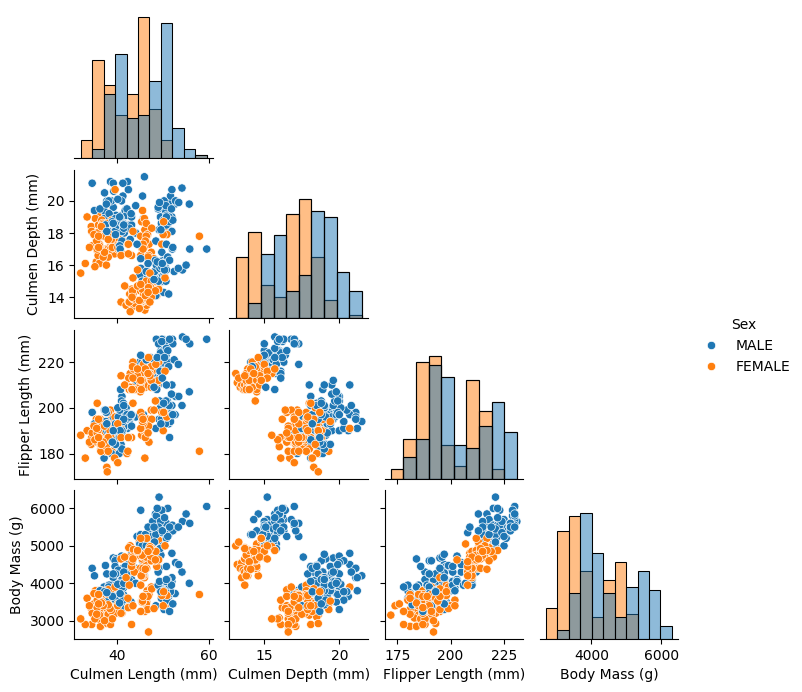

In [4]:
# Übersicht mittels pairplot
sea.pairplot(data=penguins, hue='Sex', corner=True, diag_kind='hist', height=1.75)
plt.show()

### Lineare Regression

Einfache Lineare Regression für Body Mass (*abhängige Variable*) basierend auf Flipper Length (*unabhängige Variable*). 

Package: [*statsmodels*](https://www.statsmodels.org/stable/index.html)

Struktur für die lineare Regression ist:

*var = sm.add_constant(x, prepend=True)*

*model = sm.OLS(y, var)*

*res = model.fit()*

[Beispiel mit statsmodels package](https://www.statsmodels.org/stable/examples/notebooks/generated/ols.html)

[Dokumentation der Methode (OLS)](https://www.statsmodels.org/stable/generated/statsmodels.regression.linear_model.OLS.html#statsmodels.regression.linear_model.OLS)

#### Datenvorbereitung 

Aufteilung in Test- und Trainingsdaten mit [train_test_split](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.train_test_split.html)

In [5]:
col = 'Flipper Length (mm)' # gewähltes unabhängiges Merkmal
target = 'Body Mass (g)' # abhängiges Merkmal

# 80% der Daten als Trainingsdaten
x_train, x_test, y_train, y_test = train_test_split(penguins[col], penguins[target], train_size=0.8)

print('Anzahl Beobachtungen im Trainingsdatensatz: ', x_train.shape[0])
print('Anzahl Beobachtungen im Trainingsdatensatz: ', x_test.shape[0])

Anzahl Beobachtungen im Trainingsdatensatz:  267
Anzahl Beobachtungen im Trainingsdatensatz:  67


#### Lineare Regression

In [6]:
var = sm.add_constant(x_train,prepend=True)
model = sm.OLS(y_train, var) 
res = model.fit()
display(res.summary())

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:          Body Mass (g)   R-squared:                       0.758
Model:                            OLS   Adj. R-squared:                  0.757
Method:                 Least Squares   F-statistic:                     831.1
Date:                Wed, 29 Oct 2025   Prob (F-statistic):           1.11e-83
Time:                        12:15:11   Log-Likelihood:                -1977.2
No. Observations:                 267   AIC:                             3958.
Df Residuals:                     265   BIC:                             3966.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const               -5707.3162    346.272    -16.482      0.000   -6389.111   -5025.522
Flipper Length (mm)    49.4087      1.714     28.830      0.000      46.034      52.783
==============================================================================
Omnibus:                        4.135   Durbin-Watson:                   2.162
Prob(Omnibus):                  0.126   Jarque-Bera (JB):                3.935
Skew:                           0.295   Prob(JB):                        0.140
Kurtosis:                       3.072   Cond. No.                     2.86e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.86e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

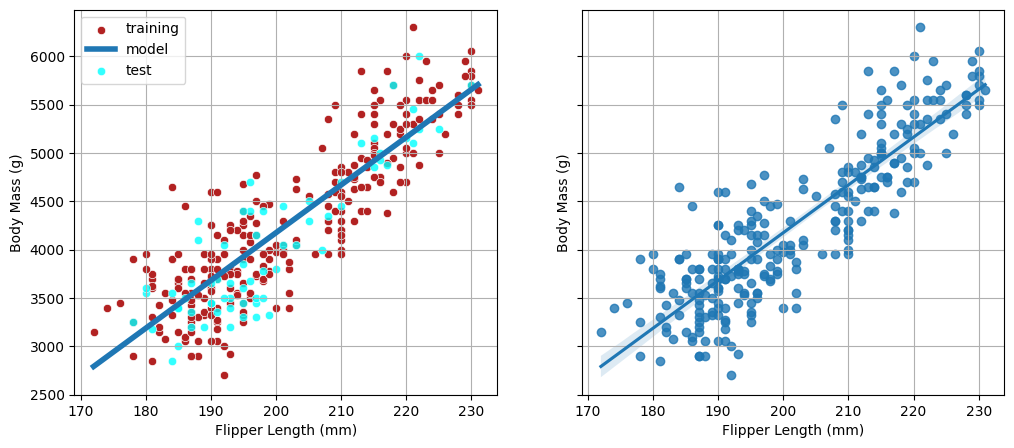

In [7]:
# Vorhersage basierend auf den Testdaten
# muss die gleiche Struktur (also mit Konstante) haben
pred = res.predict(sm.add_constant(x_test,prepend=True))

# grafische Darstellung
fig, axs = plt.subplots(1,2,figsize=(12,5), sharex=True, sharey=True)
cax = axs[0]
sea.scatterplot(x=x_train, y=y_train, ax=cax, alpha=1, color='firebrick', label='training')
sea.lineplot(x=x_train, y=res.fittedvalues, ax=cax, label='model', linewidth=4)
sea.scatterplot(x=x_test, y=y_test, ax=cax, alpha=0.8, color='aqua', label='test')
cax.grid()
cax.legend()

# via seaborn regplot: https://seaborn.pydata.org/generated/seaborn.regplot.html
cax = axs[1]
sea.regplot(x=x_train, y=y_train, ax = cax)
cax.grid()
plt.show()

In [8]:
for i in range(5):
    # 80% der Daten als Trainingsdaten
    x_train, x_test, y_train, y_test = train_test_split(penguins[col], penguins[target], train_size=0.8, random_state=None)

    # Lineare Regression
    var = sm.add_constant(x_train,prepend=True)
    model = sm.OLS(y_train, var) 
    res = model.fit()
    pred = res.predict(sm.add_constant(x_test,prepend=True))

    # grobe Auswertung
    print('Lauf {0}'.format(i+1))
    print('Quadarierte Abweichung in den Testdaten: {0:.4g}'.format(np.sum((y_test - pred)**2)))
    print('R-Quadrat: {0:.4f}'.format(res.rsquared))
    # Benutzung von r2_score, um Bestimmtheitsmaß für die Testdaten zu bestimmen
    # r2_score: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.r2_score.html
    print('R-Quadrat (Test): {0:.4f}\n'.format(r2_score(y_test, pred)))

Lauf 1
Quadarierte Abweichung in den Testdaten: 7.996e+06
R-Quadrat: 0.7641
R-Quadrat (Test): 0.7442

Lauf 2
Quadarierte Abweichung in den Testdaten: 1.157e+07
R-Quadrat: 0.7705
R-Quadrat (Test): 0.7266

Lauf 3
Quadarierte Abweichung in den Testdaten: 8.195e+06
R-Quadrat: 0.7494
R-Quadrat (Test): 0.8109

Lauf 4
Quadarierte Abweichung in den Testdaten: 1.009e+07
R-Quadrat: 0.7611
R-Quadrat (Test): 0.7661

Lauf 5
Quadarierte Abweichung in den Testdaten: 1.01e+07
R-Quadrat: 0.7621
R-Quadrat (Test): 0.7565



In [9]:
# Lineare Regression in scikit learn
x_train_vec = x_train.values.reshape(-1,1)
y_train_vec =  y_train.values.reshape(-1,1)
reg = LinearRegression().fit(x_train_vec, y_train_vec)
print('R-Quadrat: {0:.4f}'.format(reg.score(x_train_vec, y_train_vec)))
pred = reg.predict(x_test.values.reshape(-1,1))
print('R-Quadrat (Test): {0:.4f}\n'.format(reg.score(x_test.values.reshape(-1,1), y_test.values.reshape(-1,1))))

# Cross-validation
scores = cross_val_score(reg, x_train_vec, y_train_vec, cv=5)
print('R-Quadrat Werte für Training: ', scores)

R-Quadrat: 0.7621
R-Quadrat (Test): 0.7565

R-Quadrat Werte für Training:  [0.71310786 0.76345623 0.67687297 0.809995   0.79561522]


#### Frage

Führe die gleiche einfache lineare Regression durch, aber diesmal pro Pinguinart. Gib an, wieviele Datenpunkte im jeweiligen Trainingsatz sind. 
- Gibt es eine Art, für die die lineare Regression "besser" funktioniert als für andere Arten?
- Wieso könnte dies der Fall sein?

Anzahl Beobachtungen im Trainingsdatensatz Adelie:  116
Anzahl Beobachtungen im Trainingsdatensatz Adelie:  30
Anzahl Beobachtungen im Trainingsdatensatz Chinstrap:  54
Anzahl Beobachtungen im Trainingsdatensatz Chinstrap:  14
Anzahl Beobachtungen im Trainingsdatensatz Gentoo:  96
Anzahl Beobachtungen im Trainingsdatensatz Gentoo:  24


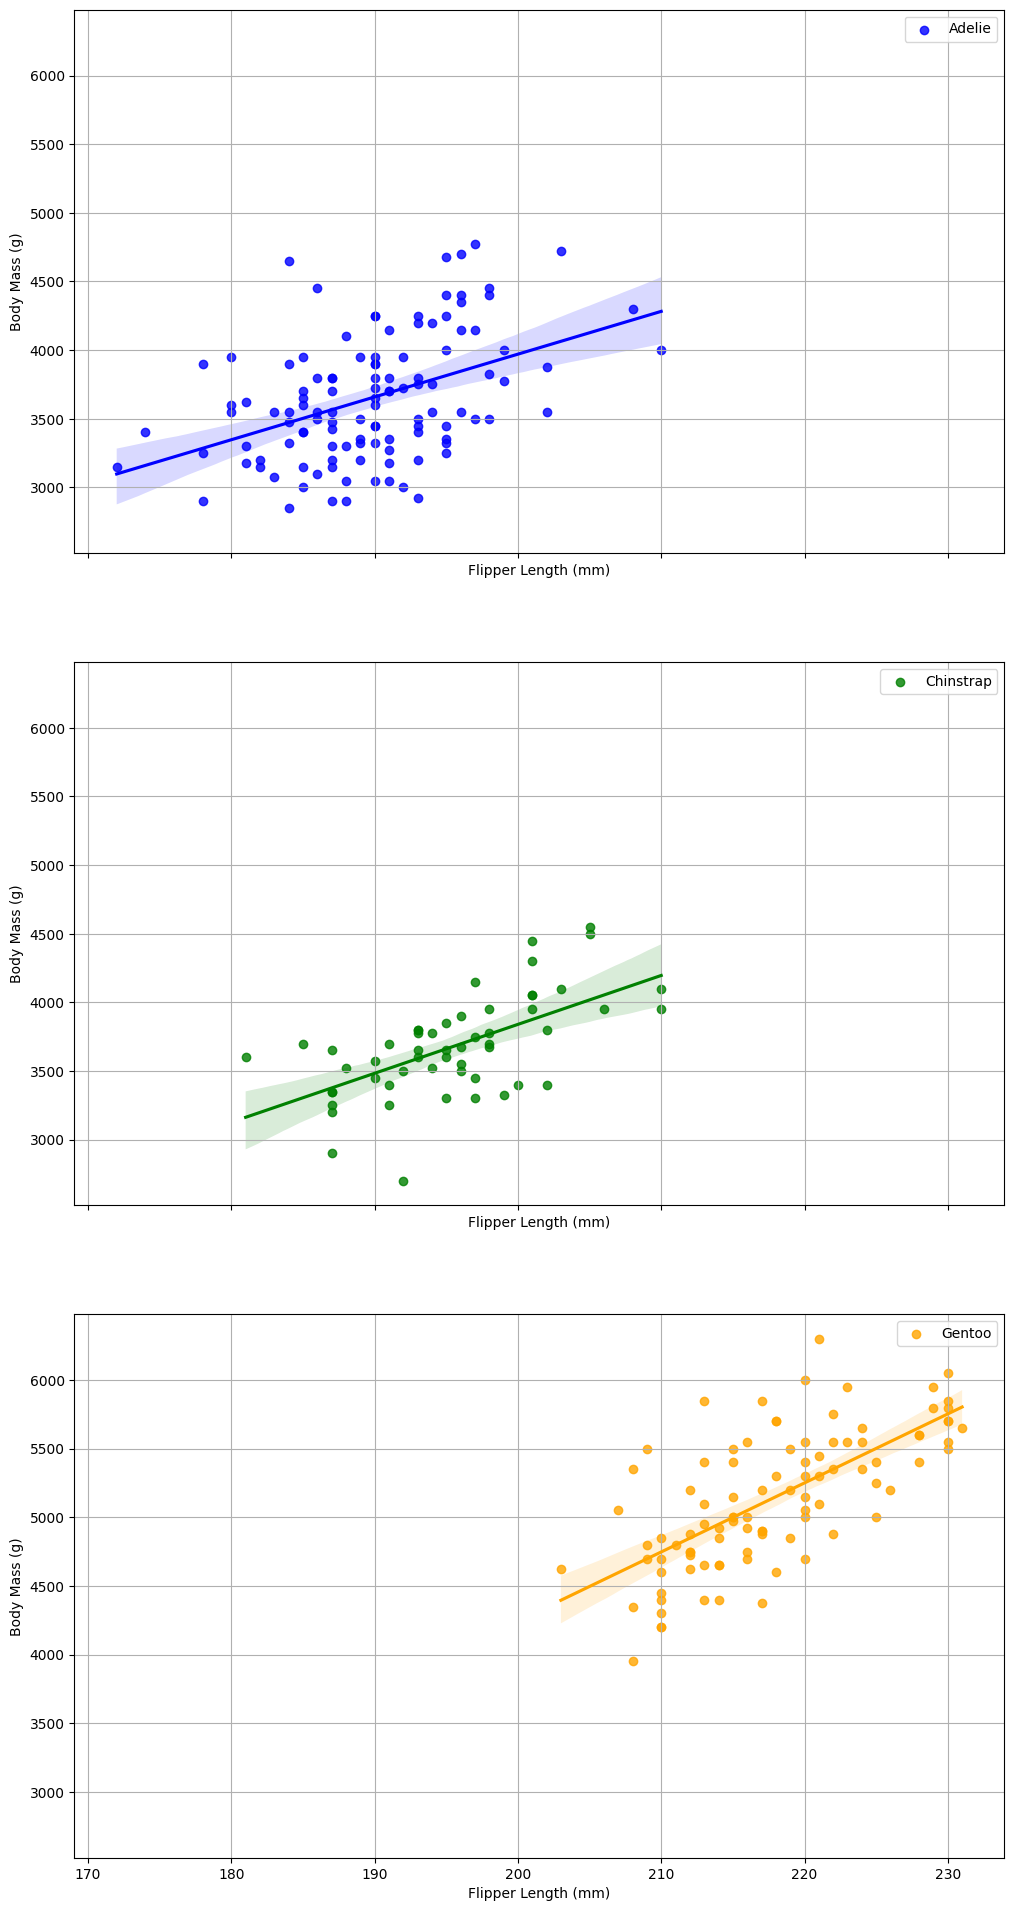

In [27]:
PenAdelie = penguins[penguins['Species']=='Adelie']
PenChinstrap = penguins[penguins['Species']=='Chinstrap']
PenGentoo = penguins[penguins['Species']=='Gentoo']


col = 'Flipper Length (mm)' # gewähltes unabhängiges Merkmal
target = 'Body Mass (g)' # abhängiges Merkmal

# 80% der Daten als Trainingsdaten
x_trainAd, x_testAd, y_trainAd, y_testAd = train_test_split(PenAdelie[col], PenAdelie[target], train_size=0.8)
x_trainCh, x_testCh, y_trainCh, y_testCh = train_test_split(PenChinstrap[col], PenChinstrap[target], train_size=0.8)
x_trainGe, x_testGe, y_trainGe, y_testGe = train_test_split(PenGentoo[col], PenGentoo[target], train_size=0.8)


print('Anzahl Beobachtungen im Trainingsdatensatz Adelie: ', x_trainAd.shape[0])
print('Anzahl Beobachtungen im Trainingsdatensatz Adelie: ', x_testAd.shape[0])
print('Anzahl Beobachtungen im Trainingsdatensatz Chinstrap: ', x_trainCh.shape[0])
print('Anzahl Beobachtungen im Trainingsdatensatz Chinstrap: ', x_testCh.shape[0])
print('Anzahl Beobachtungen im Trainingsdatensatz Gentoo: ', x_trainGe.shape[0])
print('Anzahl Beobachtungen im Trainingsdatensatz Gentoo: ', x_testGe.shape[0])

# grafische Darstellung
fig, axs = plt.subplots(3,1,figsize=(12,24), sharex=True, sharey=True)
cax = axs[0]
sea.regplot(x=x_trainAd, y=y_trainAd, ax=cax, label='Adelie', color='blue')
cax.grid(True)
cax.legend()
cax = axs[1]
sea.regplot(x=x_trainCh, y=y_trainCh, ax=cax, label='Chinstrap', color='green')
cax.grid(True)
cax.legend()
cax = axs[2]
sea.regplot(x=x_trainGe, y=y_trainGe, ax=cax, label='Gentoo', color='orange')
cax.grid(True)
cax.legend()
plt.show()

### Visualisierung der Residuen

verschiedene Versionen:
- Streudiagramm der Residuen
- Vergleich der Verteilungen
- q-q Plot


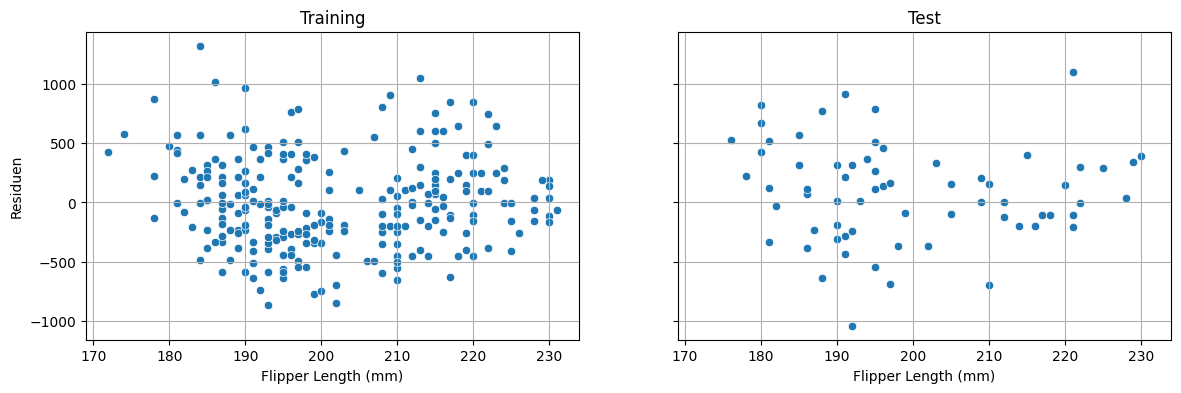

In [10]:
# nochmals die lineare regession
col = 'Flipper Length (mm)' # gewähltes unabhängiges Merkmal
target = 'Body Mass (g)' # abhängiges Merkmal
x_train, x_test, y_train, y_test = train_test_split(penguins[col], penguins[target], train_size=0.8)
var = sm.add_constant(x_train, prepend=True)
model = sm.OLS(y_train, var) 
res = model.fit()
pred = res.predict(sm.add_constant(x_test, prepend=True))

# Streudiagramm
fig, axs = plt.subplots(1, 2, figsize=(14,4), sharex=True, sharey=True)
cax = axs[0]
sea.scatterplot(y=res.resid, x=x_train, ax=cax)
cax.set_title('Training')
cax.set_ylabel('Residuen')
cax.grid()

cax = axs[1]
error = y_test - pred
sea.scatterplot(y=error, x=x_test, ax=cax)
cax.set_title('Test')
cax.grid()

plt.show()

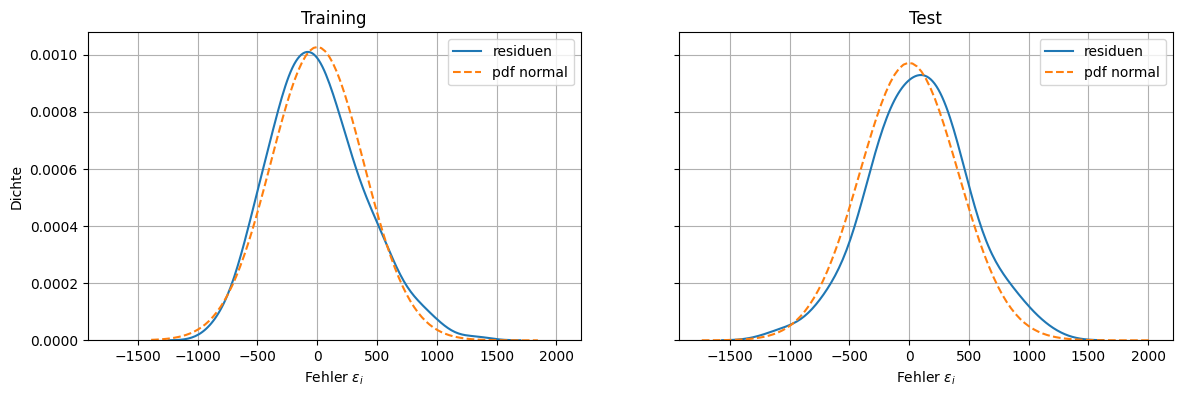

In [11]:
# Fehlerverteilung mittels kde-plot
# kde-plot: https://seaborn.pydata.org/generated/seaborn.kdeplot.html
fig, axs = plt.subplots(1, 2, figsize=(14,4), sharex=True, sharey=True)
cax = axs[0]
sea.kdeplot(res.resid, ax=cax, label='residuen')
# empirische Verteilung durch Normalverteilung approximiert
rv = stats.norm(loc=0, scale=np.std(res.resid, ddof=2))
xmin, xmax = cax.get_xlim()
xx = np.linspace(xmin, xmax, 101)
sea.lineplot(x=xx, y=rv.pdf(xx), linestyle='--', label='pdf normal', ax=cax)
cax.set_xlabel('Fehler $\epsilon_i$')
cax.set_ylabel('Dichte')
cax.set_title('Training')
cax.grid()

cax = axs[1]
error = y_test - pred
sea.kdeplot(error, ax=cax, label='residuen')
# empirische Verteilung durch Normalverteilung approximiert
rv = stats.norm(loc=0, scale=np.std(error, ddof=2))
xmin, xmax = cax.get_xlim()
xx = np.linspace(xmin, xmax, 101)
sea.lineplot(x=xx, y=rv.pdf(xx), linestyle='--', label='pdf normal', ax=cax)
cax.set_xlabel('Fehler $\epsilon_i$')
cax.set_ylabel('Dichte')
cax.set_title('Test')
cax.grid()

plt.show()

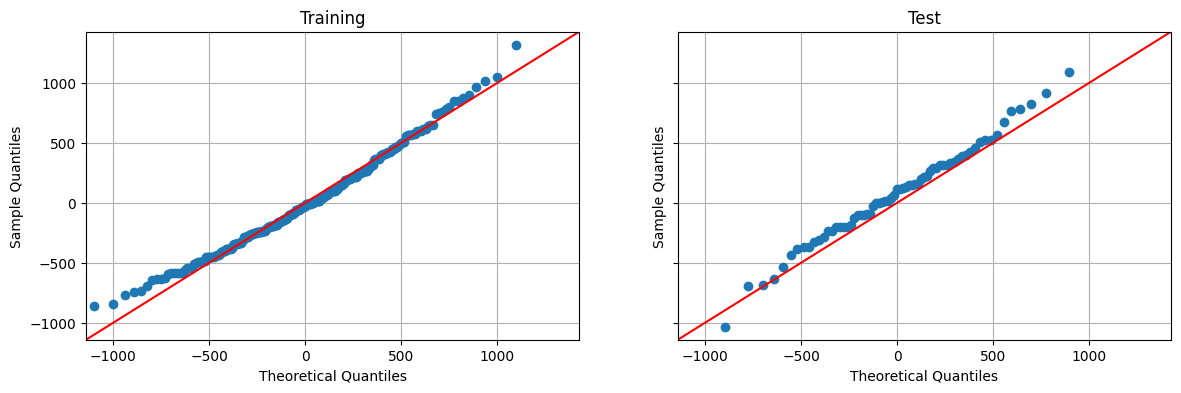

In [12]:
# mittels qq-plot (aus statsmodels)
# qq-plot: https://www.statsmodels.org/stable/generated/statsmodels.graphics.gofplots.qqplot.html
fig, axs = plt.subplots(1, 2, figsize=(14,4), sharex=True, sharey=True)
cax = axs[0]
sm.qqplot(res.resid, rv, line='45', ax=cax)
cax.set_title('Training')
cax.grid()

cax = axs[1]
error = y_test - pred
sm.qqplot(error, rv, line='45', ax=cax)
cax.set_title('Test')
cax.grid()

plt.show()

#### Frage

Führe eine einfache lineare Regression durch, um das Body Mass der Adelie-Pinguine *bestmöglichst* zu bestimmen. Inwieweit unterscheiden sich die Werte des Bestimmtheitsmasses und die Residuen, bei Benutzung der anderen metrischen Merkmale?